# 1. Data Cleaning and Preprocessing 

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r'C:\Users\2023\Downloads\.ipynb_checkpoints\marvel_characters_dataset-checkpoint.csv')


In [3]:
df.head(10)

,Character,Real Name,Affiliation,Powers,Role,Power Level
0,iron man,Tony Stark,Avengers,"Powered Armor, Genius-level intellect",Hero,Low
1,captain america,Steve Rogers,Avengers,"Super Soldier, Enhanced strength",Hero,Low
2,thor,Thor Odinson,Avengers,"God of Thunder, Weather manipulation",Hero,Low
3,black widow,Natasha Romanoff,Avengers,"Superhuman strength, Espionage",Hero,Low
4,hulk,Bruce Banner,Avengers,"Superhuman strength, Gamma Radiation",Hero,Low
5,spider-man,Peter Parker,Avengers,"Spider sense, Wall crawling",Hero,Low
6,wolverine,James Howlett,X-Men,"Regeneration, Adamantium claws",Hero,Low
7,deadpool,Wade Wilson,X-Force,"Regeneration, Skilled hand-to-hand combatant",Antihero,Low
8,black panther,T’Challa,Avengers,"Superhuman strength, Vibranium suit",Hero,Low
9,doctor strange,Stephen Strange,Avengers,"Sorcery, Magic",Hero,Low


In [4]:
df.tail(10)

,Character,Real Name,Affiliation,Powers,Role,Power Level
36,mister fantastic,Johnny Storm,Fantastic Four,"Elasticity, Superhuman strength",Hero,Low
37,invisible woman,Ben Grimm,Fantastic Four,"Invisibility, Force field generation",Hero,Low
38,human torch,Otto Octavius,Fantastic Four,"Pyrokinesis, Flight",Hero,Low
39,thing,Quentin Beck,Sinister Six,"Superhuman strength, Durability",Hero,Low
40,doctor octopus,Mac Gargan,Sinister Six,"Superhuman strength, Tentacle control",Hero,Low
41,mysterio,Eddie Brock,Sinister Six,"Illusion creation, Hypnosis",Villain,Low
42,rhino,Carol Danvers,Sinister Six,"Superhuman strength, Durability",Villain,Low
43,venom,Eddie Brock,Avengers,"Symbiote bonding, Enhanced strength",Antihero,Low
44,captain marvel,Carol Danvers,Avengers,"Flight, Superhuman strength, Cosmic energy",Hero,Low
45,deadpool,Wade Wilson,X-Force,"Regeneration, Skilled hand-to-hand combatant",Antihero,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Character    46 non-null     object
 1   Real Name    46 non-null     object
 2   Affiliation  46 non-null     object
 3   Powers       46 non-null     object
 4   Role         46 non-null     object
 5   Power Level  46 non-null     object
dtypes: object(6)
memory usage: 2.3+ KB


In [6]:
print(df.isnull().sum())

Character      0
Real Name      0
Affiliation    0
Powers         0
Role           0
Power Level    0
dtype: int64


In [7]:
df.shape

(46, 6)

In [8]:
df.duplicated().sum()

1

In [9]:
df=df.drop_duplicates()

In [10]:
df.duplicated().sum()

0

In [11]:
df.dtypes

Character      object
Real Name      object
Affiliation    object
Powers         object
Role           object
Power Level    object
dtype: object

In [12]:
df.columns

Index(['Character', 'Real Name', 'Affiliation', 'Powers', 'Role',
       'Power Level'],
      dtype='object')

In [13]:
df.describe()

,Character,Real Name,Affiliation,Powers,Role,Power Level
count,45,45,45,45,45,45
unique,44,41,10,38,3,1
top,black widow,Carol Danvers,Avengers,"Superhuman strength, Durability",Hero,Low
freq,2,2,23,3,35,45


# 2. Exploratory Data Analysis (EDA) 

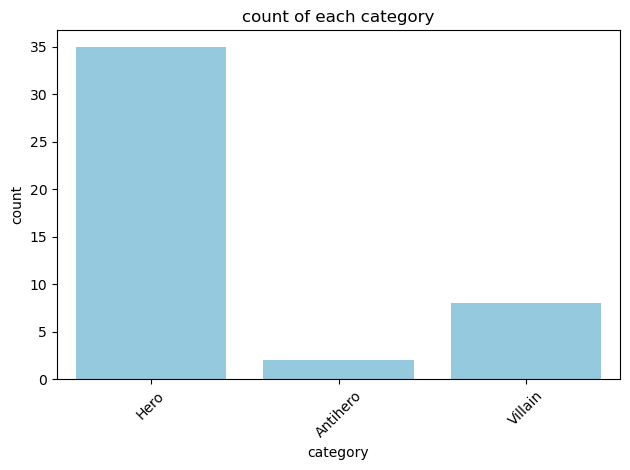

In [14]:
sns.countplot(data=df,x='Role',color='skyblue')
plt.title('count of each category')
plt.xlabel('category')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

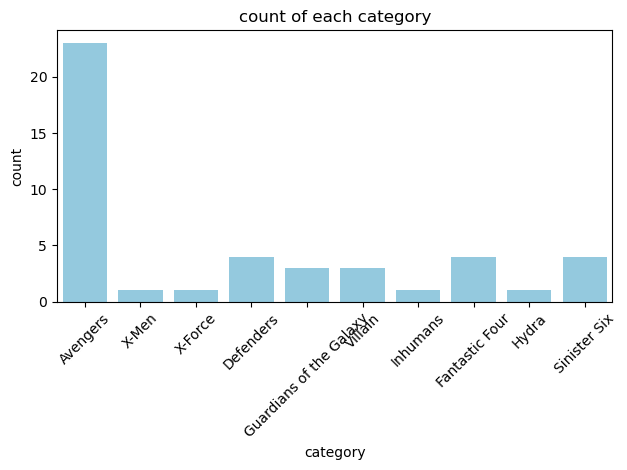

In [15]:
sns.countplot(data=df,x='Affiliation',color='skyblue')
plt.title('count of each category')
plt.xlabel('category')
plt.ylabel('count')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

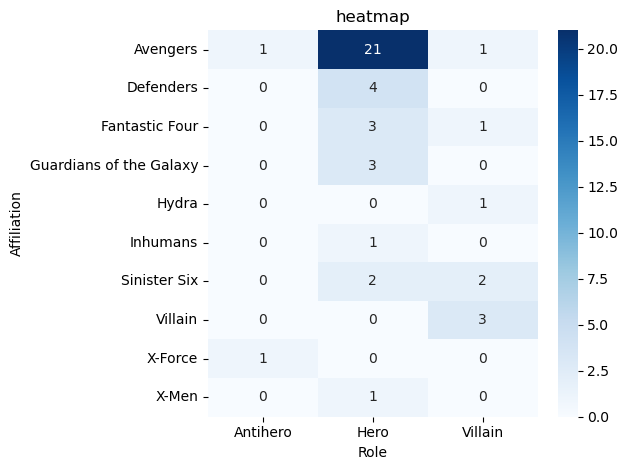

In [16]:
cross_tab=pd.crosstab(df['Affiliation'],df['Role'])
sns.heatmap(cross_tab,annot=True,cmap='Blues')
plt.title('heatmap')
plt.tight_layout()
plt.show()


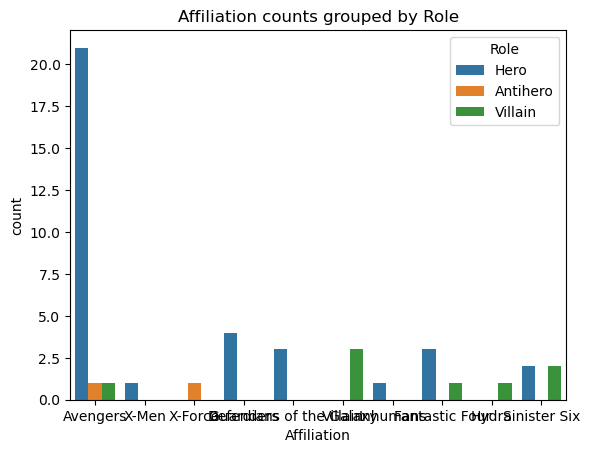

In [17]:
sns.countplot(data=df,x='Affiliation',hue='Role')
plt.title('Affiliation counts grouped by Role')
plt.xlabel('Affiliation')
plt.ylabel('count')
plt.show()

# 3. Modeling and Prediction 

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [42]:
le_affil = LabelEncoder()
df["Affiliation_encoded"] = le_affil.fit_transform(df["Affiliation"])

le_role = LabelEncoder()
df["Role_encoded"] = le_role.fit_transform(df["Role"])

le_power = LabelEncoder()
df["Power_Level_encoded"] = le_power.fit_transform(df["Power Level"])


In [43]:
X = df[["Affiliation_encoded", "Power_Level_encoded"]]
y = df["Role_encoded"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [45]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.6666666666666666
